# 02 - Feature Engineering

Строим признаки из всех таблиц и собираем финальный датасет.

**Pipeline:**
1. Загружаем `application_train.csv`
2. Добавляем новые признаки из главной таблицы
3. Агрегируем каждую вспомогательную таблицу → одна строка на клиента
4. LEFT JOIN всех агрегатов по `SK_ID_CURR`
5. One-hot encoding категориальных признаков
6. Сохраняем в `data/processed/final_train.parquet`

In [1]:
import sys
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

ROOT = Path('..').resolve()
sys.path.insert(0, str(ROOT))

from src.features.application_features import build_application_features
from src.features.bureau_features import build_bureau_features
from src.features.previous_features import build_previous_features
from src.features.installment_features import build_installment_features
from src.features.pos_cash_features import build_pos_cash_features
from src.features.credit_card_features import build_credit_card_features

print('Libraries loaded')

Libraries loaded


## 1. Application features

In [2]:
df = pd.read_csv('../data/application_train.csv')
print(f'Raw shape: {df.shape}')

df = build_application_features(df)
print(f'After application features: {df.shape}')

new_cols = [
    'AGE_YEARS', 'IS_UNEMPLOYED', 'YEARS_EMPLOYED',
    'CREDIT_INCOME_RATIO', 'ANNUITY_INCOME_RATIO', 'CREDIT_GOODS_RATIO',
    'EXT_SOURCE_MEAN', 'EXT_SOURCE_MIN', 'EXT_SOURCE_MAX', 'EXT_SOURCE_STD',
    'INCOME_PER_PERSON', 'EMPLOYED_TO_AGE_RATIO',
    'DOCUMENT_COUNT', 'AMT_REQ_CREDIT_BUREAU_TOTAL'
]
df[new_cols].describe().round(3)

Raw shape: (307511, 122)
After application features: (307511, 141)


,AGE_YEARS,IS_UNEMPLOYED,YEARS_EMPLOYED,CREDIT_INCOME_RATIO,ANNUITY_INCOME_RATIO,CREDIT_GOODS_RATIO,EXT_SOURCE_MEAN,EXT_SOURCE_MIN,EXT_SOURCE_MAX,EXT_SOURCE_STD,INCOME_PER_PERSON,EMPLOYED_TO_AGE_RATIO,DOCUMENT_COUNT,AMT_REQ_CREDIT_BUREAU_TOTAL
count,307511.000,307511.000,252137.000,307511.000,307499.000,307233.000,307339.000,307339.000,307339.000,270602.000,3.075090e+05,252137.000,307511.000,307511.000
mean,43.937,0.180,6.532,3.958,0.181,1.123,0.509,0.400,0.616,0.151,5.748225e+04,0.157,0.930,2.146
std,11.956,0.384,6.406,2.690,0.095,0.124,0.150,0.187,0.156,0.100,6.585166e+04,0.134,0.344,2.291
min,20.518,0.000,-0.000,0.005,0.000,0.150,0.000,0.000,0.000,0.000,2.647059e+03,-0.000,0.000,0.000
25%,34.008,0.000,2.101,2.019,0.115,1.000,0.414,0.254,0.541,0.072,3.375000e+04,0.056,1.000,0.000
50%,43.151,0.000,4.515,3.265,0.163,1.119,0.525,0.403,0.648,0.136,4.950000e+04,0.119,1.000,2.000
75%,53.923,0.000,8.699,5.160,0.229,1.198,0.623,0.553,0.725,0.214,6.750000e+04,0.219,1.000,3.000
max,69.121,1.000,49.074,84.737,1.876,6.000,0.879,0.879,0.963,0.652,2.925000e+07,0.729,4.000,262.000


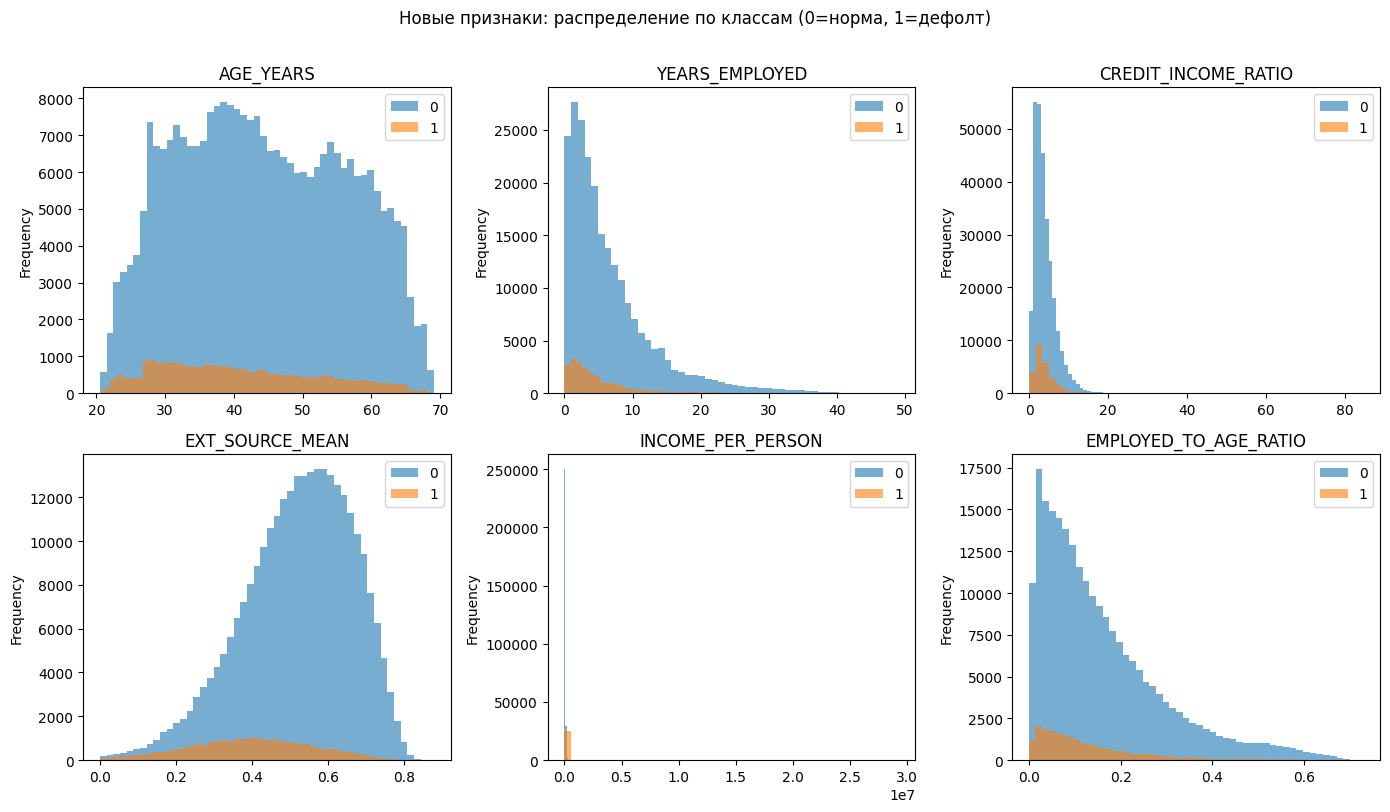

In [3]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
plot_cols = ['AGE_YEARS', 'YEARS_EMPLOYED', 'CREDIT_INCOME_RATIO',
             'EXT_SOURCE_MEAN', 'INCOME_PER_PERSON', 'EMPLOYED_TO_AGE_RATIO']

for ax, col in zip(axes.flat, plot_cols):
    df.groupby('TARGET')[col].plot(kind='hist', ax=ax, bins=50, alpha=0.6, legend=True)
    ax.set_title(col)
    ax.set_xlabel('')

plt.suptitle('Новые признаки: распределение по классам (0=норма, 1=дефолт)', y=1.01)
plt.tight_layout()
plt.show()

## 2. Bureau features

In [4]:
print('Loading bureau.csv...')
bureau = pd.read_csv('../data/bureau.csv')
print('Loading bureau_balance.csv...')
bureau_balance = pd.read_csv('../data/bureau_balance.csv')

bureau_feats = build_bureau_features(bureau, bureau_balance)
del bureau, bureau_balance

print(f'Bureau features shape: {bureau_feats.shape}')
bureau_feats.head(3)

Loading bureau.csv...
Loading bureau_balance.csv...
Bureau features shape: (305811, 30)


,SK_ID_CURR,BUREAU_LOAN_COUNT,BUREAU_ACTIVE_COUNT,BUREAU_CLOSED_COUNT,AMT_CREDIT_SUM_SUM,AMT_CREDIT_SUM_MEAN,AMT_CREDIT_SUM_MAX,AMT_CREDIT_SUM_DEBT_SUM,AMT_CREDIT_SUM_DEBT_MEAN,AMT_CREDIT_SUM_DEBT_MAX,...,CNT_CREDIT_PROLONG_SUM,CNT_CREDIT_PROLONG_MAX,AMT_ANNUITY_SUM,AMT_ANNUITY_MEAN,BB_MONTHS_COUNT_SUM,BB_STATUS_C_COUNT_SUM,BB_STATUS_DPD_COUNT_SUM,BUREAU_ACTIVE_DEBT_SUM,BUREAU_ACTIVE_CREDIT_SUM,BUREAU_ACTIVE_OVERDUE_SUM
0,100001,7,3,4,1453365.000,207623.571429,378000.0,596686.5,85240.928571,373239.0,...,0,0,24817.5,3545.357143,172.0,110.0,1.0,596686.5,884025.000,0.0
1,100002,8,2,6,865055.565,108131.945625,450000.0,245781.0,49156.200000,245781.0,...,0,0,0.0,0.000000,110.0,23.0,27.0,245781.0,481988.565,0.0
2,100003,4,1,3,1017400.500,254350.125000,810000.0,0.0,0.000000,0.0,...,0,0,0.0,NaN,0.0,0.0,0.0,0.0,810000.000,0.0


## 3. Previous application features

In [5]:
print('Loading previous_application.csv...')
prev = pd.read_csv('../data/previous_application.csv')

prev_feats = build_previous_features(prev)
del prev

print(f'Previous features shape: {prev_feats.shape}')
prev_feats.head(3)

Loading previous_application.csv...
Previous features shape: (338857, 20)


,SK_ID_CURR,PREV_LOAN_COUNT,PREV_AMT_APPLICATION_MEAN,PREV_AMT_APPLICATION_MAX,PREV_AMT_CREDIT_MEAN,PREV_AMT_CREDIT_SUM,PREV_AMT_ANNUITY_MEAN,PREV_AMT_DOWN_PAYMENT_MEAN,PREV_RATE_DOWN_PAYMENT_MEAN,PREV_APP_CREDIT_RATIO_MEAN,PREV_DAYS_DECISION_MEAN,PREV_DAYS_DECISION_MIN,PREV_CNT_PAYMENT_MEAN,PREV_CNT_PAYMENT_SUM,PREV_APPROVED_COUNT,PREV_APPROVED_AMT_CREDIT_MEAN,PREV_APPROVED_AMT_ANNUITY_MEAN,PREV_REFUSED_COUNT,PREV_APPROVED_RATIO,PREV_REFUSED_RATIO
0,100001,1,24835.5,24835.5,23787.0,23787.0,3951.000,2520.0,0.104326,1.044079,-1740.0,-1740,8.0,8.0,1.0,23787.0,3951.000,NaN,1.0,NaN
1,100002,1,179055.0,179055.0,179055.0,179055.0,9251.775,0.0,0.000000,1.000000,-606.0,-606,24.0,24.0,1.0,179055.0,9251.775,NaN,1.0,NaN
2,100003,3,435436.5,900000.0,484191.0,1452573.0,56553.990,3442.5,0.050030,0.949329,-1305.0,-2341,10.0,30.0,3.0,484191.0,56553.990,NaN,1.0,NaN


## 4. Installment payment features

In [6]:
print('Loading installments_payments.csv...')
ins = pd.read_csv('../data/installments_payments.csv')

ins_feats = build_installment_features(ins)
del ins

print(f'Installment features shape: {ins_feats.shape}')
ins_feats.head(3)

Loading installments_payments.csv...
Installment features shape: (339587, 12)


,SK_ID_CURR,INS_COUNT,INS_DPD_MEAN,INS_DPD_MAX,INS_DPD_SUM,INS_OVERDUE_RATIO,INS_PAYMENT_DIFF_MEAN,INS_PAYMENT_DIFF_MAX,INS_PAYMENT_DIFF_SUM,INS_AMT_INSTALMENT_MEAN,INS_AMT_PAYMENT_MEAN,INS_PAYMENT_RATIO_MEAN
0,100001,7,7.285714,36.0,51.0,0.571429,0.0,0.0,0.0,5885.132143,5885.132143,1.0
1,100002,19,20.421053,31.0,388.0,1.000000,0.0,0.0,0.0,11559.247105,11559.247105,1.0
2,100003,25,7.160000,14.0,179.0,1.000000,0.0,0.0,0.0,64754.586000,64754.586000,1.0


## 5. POS CASH features

In [7]:
print('Loading POS_CASH_balance.csv...')
pos = pd.read_csv('../data/POS_CASH_balance.csv')

pos_feats = build_pos_cash_features(pos)
del pos

print(f'POS CASH features shape: {pos_feats.shape}')
pos_feats.head(3)

Loading POS_CASH_balance.csv...
POS CASH features shape: (337252, 12)


,SK_ID_CURR,POS_COUNT,POS_MONTHS_COUNT,POS_SK_DPD_MEAN,POS_SK_DPD_MAX,POS_SK_DPD_DEF_MEAN,POS_SK_DPD_DEF_MAX,POS_CNT_INSTALMENT_MEAN,POS_CNT_INSTALMENT_FUTURE_MEAN,POS_COMPLETED_COUNT,POS_ACTIVE_COUNT,POS_COMPLETED_RATIO
0,100001,9,9,0.777778,7,0.777778,7,4.000000,1.444444,2,7,0.222222
1,100002,19,19,0.000000,0,0.000000,0,24.000000,15.000000,0,19,0.000000
2,100003,28,28,0.000000,0,0.000000,0,10.107143,5.785714,2,26,0.071429


## 6. Credit card features

In [8]:
print('Loading credit_card_balance.csv...')
cc = pd.read_csv('../data/credit_card_balance.csv')

cc_feats = build_credit_card_features(cc)
del cc

print(f'Credit card features shape: {cc_feats.shape}')
cc_feats.head(3)

Loading credit_card_balance.csv...
Credit card features shape: (103558, 15)


,SK_ID_CURR,CC_COUNT,CC_MONTHS_COUNT,CC_AMT_BALANCE_MEAN,CC_AMT_BALANCE_MAX,CC_AMT_CREDIT_LIMIT_MEAN,CC_UTILIZATION_MEAN,CC_UTILIZATION_MAX,CC_SK_DPD_MEAN,CC_SK_DPD_MAX,CC_SK_DPD_DEF_MEAN,CC_SK_DPD_DEF_MAX,CC_AMT_DRAWINGS_TOTAL_MEAN,CC_CNT_DRAWINGS_TOTAL_MEAN,CC_AMT_PAYMENT_TOTAL_MEAN
0,100006,6,6,0.000000,0.00,270000.000000,0.000000,0.00000,0.000000,0,0.000000,0,0.000000,0.000000,NaN
1,100011,74,74,54482.111149,189000.00,164189.189189,0.302678,1.05000,0.000000,0,0.000000,0,2432.432432,0.054054,4843.064189
2,100013,96,96,18159.919219,161420.22,131718.750000,0.115301,1.02489,0.010417,1,0.010417,1,5953.125000,0.239583,7168.346250


## 7. Сборка финального датасета

In [9]:
print(f'Before join: {df.shape}')

for feats, name in [
    (bureau_feats, 'bureau'),
    (prev_feats, 'previous'),
    (ins_feats, 'installments'),
    (pos_feats, 'pos_cash'),
    (cc_feats, 'credit_card'),
]:
    df = df.merge(feats, on='SK_ID_CURR', how='left')
    print(f'After {name} join: {df.shape}')

Before join: (307511, 141)
After bureau join: (307511, 170)
After previous join: (307511, 189)
After installments join: (307511, 200)
After pos_cash join: (307511, 211)
After credit_card join: (307511, 225)


In [10]:
cat_cols = df.select_dtypes('object').columns.tolist()
print(f'Categorical columns ({len(cat_cols)}): {cat_cols}')

df = pd.get_dummies(df, columns=cat_cols, dummy_na=False)

bool_cols = df.select_dtypes(bool).columns
df[bool_cols] = df[bool_cols].astype(np.int8)

print(f'Final shape after OHE: {df.shape}')

Categorical columns (16): ['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE', 'WEEKDAY_APPR_PROCESS_START', 'ORGANIZATION_TYPE', 'FONDKAPREMONT_MODE', 'HOUSETYPE_MODE', 'WALLSMATERIAL_MODE', 'EMERGENCYSTATE_MODE']


Final shape after OHE: (307511, 349)


In [11]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).sort_values(ascending=False)

print(f'Total columns: {df.shape[1]}')
print(f'Columns with any missing: {(missing > 0).sum()}')
print(f'\nTop 20 by missing %:')
print(missing_pct.head(20).to_string())

Total columns: 349
Columns with any missing: 158

Top 20 by missing %:
CC_AMT_PAYMENT_TOTAL_MEAN     80.143800
AMT_ANNUITY_MEAN              73.981744
CC_AMT_CREDIT_LIMIT_MEAN      72.021814
CC_UTILIZATION_MAX            72.021814
CC_UTILIZATION_MEAN           72.021814
CC_SK_DPD_DEF_MAX             71.739222
CC_CNT_DRAWINGS_TOTAL_MEAN    71.739222
CC_COUNT                      71.739222
CC_AMT_BALANCE_MAX            71.739222
CC_AMT_BALANCE_MEAN           71.739222
CC_AMT_DRAWINGS_TOTAL_MEAN    71.739222
CC_SK_DPD_DEF_MEAN            71.739222
CC_SK_DPD_MEAN                71.739222
CC_SK_DPD_MAX                 71.739222
CC_MONTHS_COUNT               71.739222
COMMONAREA_AVG                69.872297
COMMONAREA_MODE               69.872297
COMMONAREA_MEDI               69.872297
NONLIVINGAPARTMENTS_MODE      69.432963
NONLIVINGAPARTMENTS_MEDI      69.432963


In [12]:
out_path = Path('../data/processed/final_train.parquet')
out_path.parent.mkdir(parents=True, exist_ok=True)
df.to_parquet(out_path, index=False)

print(f'Saved: {out_path}')
print(f'Shape: {df.shape}')
print(f'Size: {out_path.stat().st_size / 1024 / 1024:.1f} MB')

Saved: ..\data\processed\final_train.parquet
Shape: (307511, 349)
Size: 105.8 MB


## 8. Проверка корреляции новых признаков с TARGET

Top 30 признаков по корреляции с TARGET:
EXT_SOURCE_MEAN                0.222052
EXT_SOURCE_MAX                 0.196876
EXT_SOURCE_MIN                 0.185266
EXT_SOURCE_3                   0.178919
EXT_SOURCE_2                   0.160472
EXT_SOURCE_1                   0.155317
CC_UTILIZATION_MEAN            0.135560
CC_UTILIZATION_MAX             0.097011
DAYS_CREDIT_MEAN               0.089729
CC_AMT_BALANCE_MEAN            0.087177
PREV_REFUSED_RATIO             0.085187
CC_CNT_DRAWINGS_TOTAL_MEAN     0.082520
AGE_YEARS                      0.078239
DAYS_BIRTH                     0.078239
DAYS_CREDIT_MIN                0.075248
YEARS_EMPLOYED                 0.074958
DAYS_EMPLOYED                  0.074958
CREDIT_GOODS_RATIO             0.069427
DAYS_CREDIT_UPDATE_MEAN        0.068927
CC_AMT_BALANCE_MAX             0.068798
EMPLOYED_TO_AGE_RATIO          0.067955
BUREAU_ACTIVE_COUNT            0.067128
PREV_APPROVED_RATIO            0.064368
REGION_RATING_CLIENT_W_CITY    0.060893

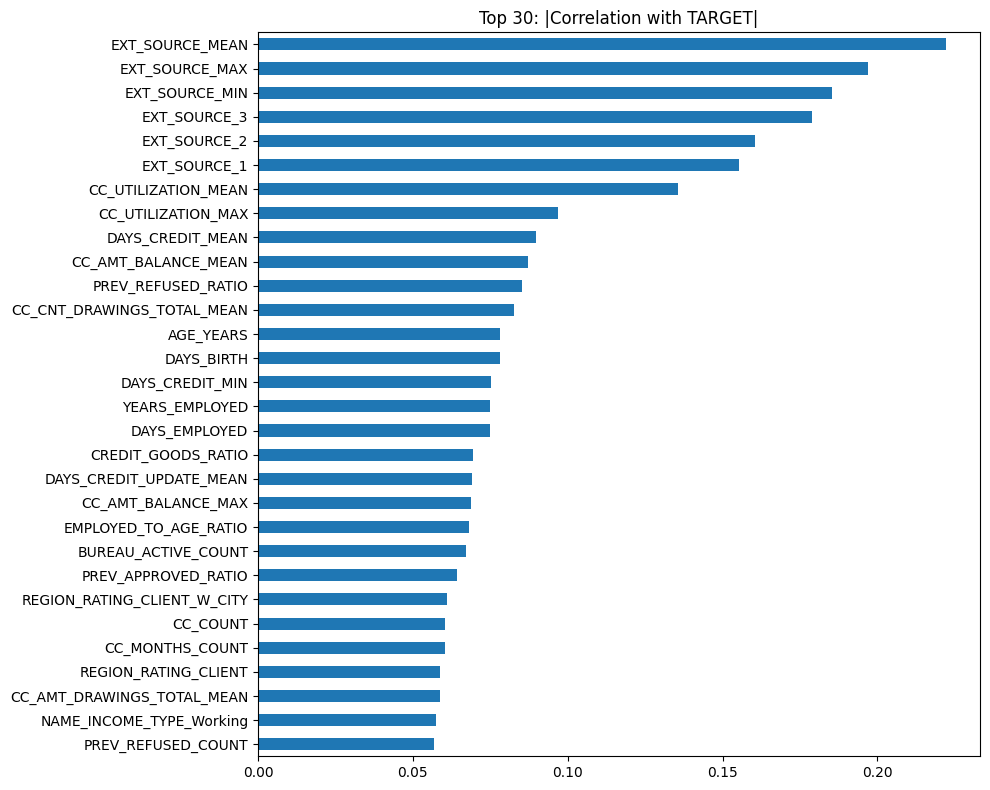

In [13]:
numeric_cols = df.select_dtypes('number').columns.drop(['SK_ID_CURR', 'TARGET'], errors='ignore')
corr = df[numeric_cols].corrwith(df['TARGET']).abs().sort_values(ascending=False)

print('Top 30 признаков по корреляции с TARGET:')
print(corr.head(30).to_string())

plt.figure(figsize=(10, 8))
corr.head(30).sort_values().plot(kind='barh')
plt.title('Top 30: |Correlation with TARGET|')
plt.tight_layout()
plt.savefig('../reports/feature_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

In [14]:
print('=== ИТОГ ===')
print(f'Финальный датасет: {df.shape[0]:,} строк, {df.shape[1]:,} признаков')
print(f'Целевая переменная: {df["TARGET"].value_counts().to_dict()}')
print(f'Дефолт: {df["TARGET"].mean():.2%}')
print(f'Файл: data/processed/final_train.parquet')

=== ИТОГ ===
Финальный датасет: 307,511 строк, 349 признаков
Целевая переменная: {0: 282686, 1: 24825}
Дефолт: 8.07%
Файл: data/processed/final_train.parquet
